In [61]:
############### Acquisition et d'Initialisation des données #################


import pandas as pd
import urllib.request
import os

# 1. Créer le dossier data s'il n'existe pas
if not os.path.exists('../data'):
    os.makedirs('../data')

# 2. L'adresse du fichier sur internet
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

# 3. Destination sur ton ordinateur
destination = "../data/heart.csv"

# 4. Téléchargement magique
try:
    urllib.request.urlretrieve(url, destination)
    print("Succès ! Le fichier est maintenant dans ton dossier /data")
    
    # 5. Vérification : On l'ouvre pour voir
    df = pd.read_csv(destination)
    display(df.head())
except Exception as e:
    print(f"Erreur : {e}")

Succès ! Le fichier est maintenant dans ton dossier /data


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [62]:
# Donne la moyenne, le min, le max pour toutes les colonnes d'un coup
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


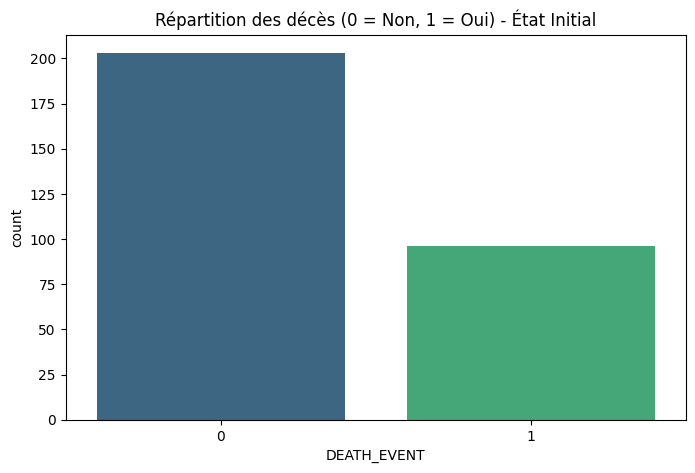

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tracé du compte des classes pour montrer le déséquilibre initial
plt.figure(figsize=(8, 5))
sns.countplot(x='DEATH_EVENT', data=df, hue='DEATH_EVENT', palette='viridis', legend=False)
plt.title('Répartition des décès (0 = Non, 1 = Oui) - État Initial')
plt.show()

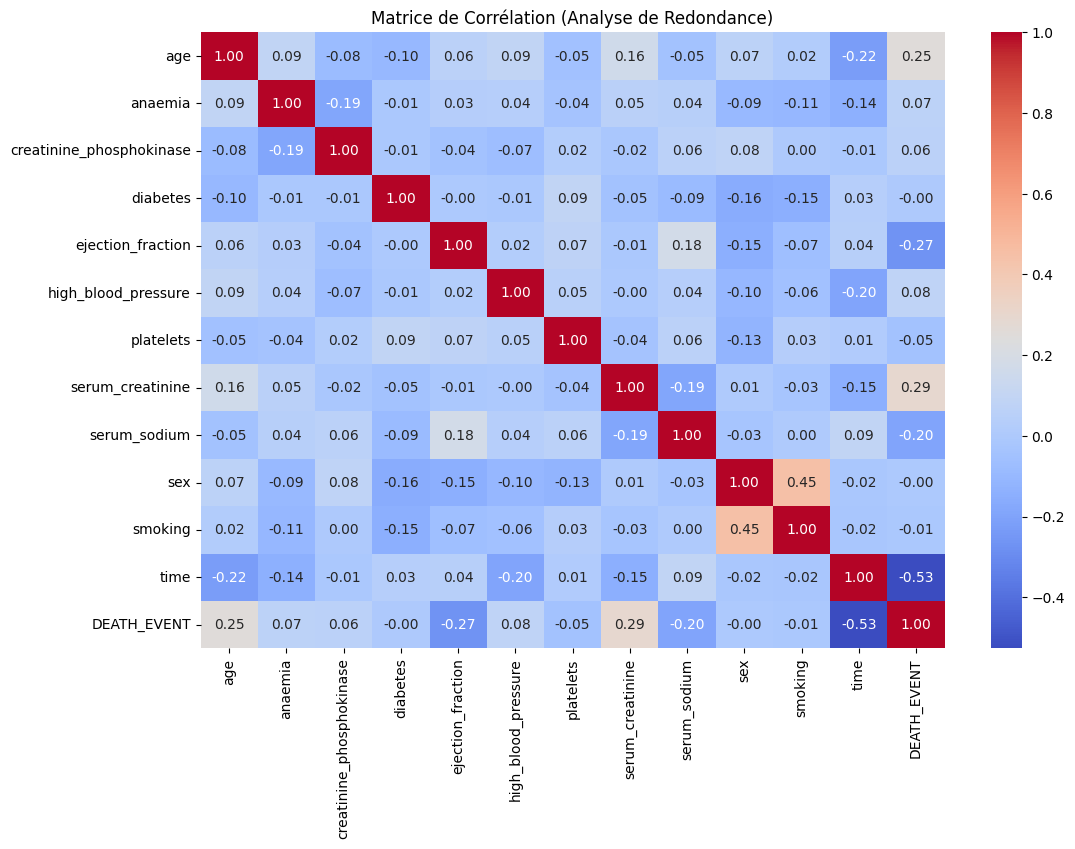

In [64]:
####### Vérification de la colinéarité et analyse de redondance ########
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# On utilise df (le dataset original) pour voir les corrélations naturelles
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de Corrélation (Analyse de Redondance)')
plt.show()

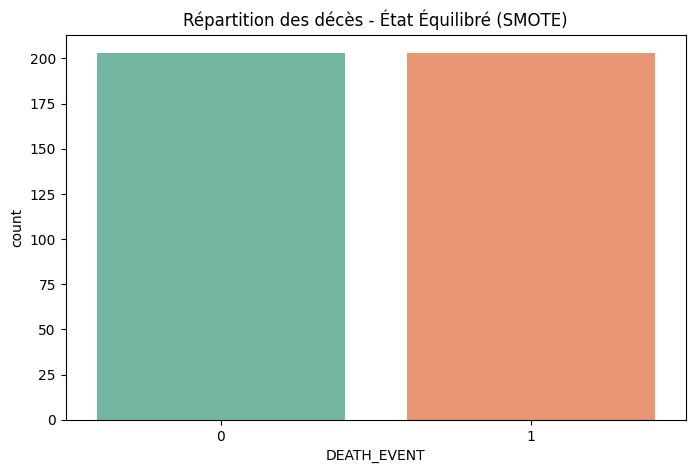

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tracé du compte des classes pour montrer l'équilibre final (406 patients)
plt.figure(figsize=(8, 5))
sns.countplot(x='DEATH_EVENT', data=df_equilibre, hue='DEATH_EVENT', palette='Set2', legend=False)
plt.title('Répartition des décès - État Équilibré (SMOTE)')
plt.show()

In [66]:

# On recrée un DataFrame complet avec les données équilibrées
df_final = pd.DataFrame(X_res, columns=X.columns)
df_final['DEATH_EVENT'] = y_res

In [67]:
##################### Optimizing Memory #####################
# --- ÉTAPE 1 : ÉTAT INITIAL ---
print("📊 ANALYSE DE LA MÉMOIRE AVANT OPTIMISATION")
print("-" * 50)

# Affichage des types actuels
print("Types de données actuels :")
print(df.dtypes)

# Calcul de l'espace occupé en KB
mem_initiale = df.memory_usage(deep=True).sum() / 1024
print("-" * 50)
print(f"Espace mémoire occupé : {mem_initiale:.2f} KB")

📊 ANALYSE DE LA MÉMOIRE AVANT OPTIMISATION
--------------------------------------------------
Types de données actuels :
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object
--------------------------------------------------
Espace mémoire occupé : 30.50 KB


In [68]:
# --- ÉTAPE 2 : LA FONCTION D'OPTIMISATION ---
import pandas as pd

def optimize_memory(df):
    """
    Réduit la taille des données en ajustant les types numériques.
    """
    for col in df.columns:
        col_type = df[col].dtype
        
        # Optimisation pour les nombres entiers
        if str(col_type).startswith('int'):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        
        # Optimisation pour les nombres décimaux
        elif str(col_type).startswith('float'):
            df[col] = pd.to_numeric(df[col], downcast='float')
            
    return df

In [69]:
# --- ÉTAPE 3 : RÉSULTAT FINAL ---
# Application de la fonction
df_optimise = optimize_memory(df)

print("🚀 RÉSULTAT APRÈS OPTIMISATION")
print("-" * 50)

# Vérification des nouveaux types (int8, int16, float32, etc.)
print("Nouveaux types de données :")
print(df_optimise.dtypes)

# Calcul du gain
mem_finale = df_optimise.memory_usage(deep=True).sum() / 1024
gain = ((mem_initiale - mem_finale) / mem_initiale) * 100

print("-" * 50)
print(f"Nouvel espace mémoire : {mem_finale:.2f} KB")
print(f"Réduction totale : {gain:.1f} %")

🚀 RÉSULTAT APRÈS OPTIMISATION
--------------------------------------------------
Nouveaux types de données :
age                         float32
anaemia                        int8
creatinine_phosphokinase      int16
diabetes                       int8
ejection_fraction              int8
high_blood_pressure            int8
platelets                   float64
serum_creatinine            float32
serum_sodium                  int16
sex                            int8
smoking                        int8
time                          int16
DEATH_EVENT                    int8
dtype: object
--------------------------------------------------
Nouvel espace mémoire : 8.60 KB
Réduction totale : 71.8 %
